<div style="display: flex; align-items: center; justify-content: center; gap: 20px;">
    <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSE9HzJ3_vGCa47A_0IH_JRqOVf7O4TzeGjtA&s" alt="Image Gauche" style="width: 300px; height: auto;">
    <div style="text-align: center;">
        <h1>
            <span style="font-weight: bold; color: #00A8E0; text-decoration: underline;">
                AT&T_spam_detector
            </span>
        </h1>
    </div>
    <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSE9HzJ3_vGCa47A_0IH_JRqOVf7O4TzeGjtA&s" alt="Image Droite" style="width: 300px; height: auto;">
</div>


## 📚 Introduction

In this notebook, we aim to build and compare several machine learning approaches to automatically classify SMS messages as spam or ham — a crucial task for telecom providers like AT&T to protect their users from fraudulent and unwanted messages.

We implement three progressively complex and complementary methods:

1. **TF-IDF + Neural Network** – a fast and interpretable baseline using manually engineered features,  
2. **Embedding Layer + Neural Network** – a more flexible model that learns word representations from scratch,  
3. **Transfer Learning with BERT** – leveraging the power of a pre-trained transformer model for high accuracy,  

Each method will be evaluated using standard classification metrics such as accuracy, precision, and recall. Our objective is to identify the best trade-off between performance, complexity, and interpretability for spam detection.


## 0️⃣ Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Spacy for nlp
!python -m spacy download en_core_web_md -q
import en_core_web_md
from spacy.lang.en.stop_words import STOP_WORDS
nlp = en_core_web_md.load()

# sklearn functions
from sklearn.utils import resample
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score

# tensorflow functions
import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras.callbacks import ModelCheckpoint
from keras.models import load_model

# Word counting
from collections import Counter

# Transformers
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from transformers import get_scheduler

# pytorch functions
import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW
from torch.nn import functional as F

# tqdm
from tqdm.auto import tqdm


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')


## 1️⃣ Data retrieval and cleaning

In [205]:
# csv retrieval

dataset = pd.read_csv("modified_src/cleaned_data.csv", encoding="ISO-8859-1")

In [206]:
# Keep only alphanumeric characters, convert to lowercase, and apply lemmatization

dataset["message_clean"] = dataset["message"].apply(lambda x:''.join(ch for ch in x if ch.isalnum() or ch==" " or ch=="'"))
dataset["message_clean"] = dataset["message_clean"].apply(lambda x: x.replace(" +"," ").lower().strip())
dataset["message_clean"] = dataset["message_clean"].apply(lambda x: " ".join([token.lemma_ for token in nlp(x) if (token.lemma_ not in STOP_WORDS) and (token.text not in STOP_WORDS)]))

dataset.head()

,label,message,message_length,message_clean
0,0,"Go until jurong point, crazy.. Available only ...",111,jurong point crazy available bugis n great wor...
1,0,Ok lar... Joking wif u oni...,29,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,49,u dun early hor u c
4,0,"Nah I don't think he goes to usf, he lives aro...",61,nah think usf live


In [207]:
# Function to oversample the minority class

def data_over_sampling(data, nb_boost):
    """
    Oversample the minority class (label == '1') by duplicating its samples.

    Parameters:
        data (pd.DataFrame): The original dataset containing a 'label' column
        nb_boost (int): The oversampling factor relative to the majority class

    Returns:
        pd.DataFrame: A new dataset with oversampled minority class, shuffled
    """
    # Select majority class (label '0') and minority class (label '1')
    data_sample_1 = data.loc[data['label'] == 0, :]
    data_sample_2 = data.loc[data['label'] == 1, :]

    # Oversample the minority class with replacement
    data_sample_2 = resample(data_sample_2, 
                             replace=True,  # Sample with replacement
                             n_samples=nb_boost * len(data_sample_1), 
                             random_state=42)  # For reproducibility

    # Combine majority and oversampled minority, then shuffle
    return pd.concat([data_sample_1, data_sample_2], axis=0).sample(frac=1).reset_index(drop=True)

In [208]:
# Application on dataset_1

data_oversampled = data_over_sampling(dataset, 1)
data_oversampled['label'].value_counts()

label
1    4825
0    4825
Name: count, dtype: int64

In [209]:
# Quick visualization

data_oversampled.head()

,label,message,message_length,message_clean
0,1,Adult 18 Content Your video will be with you s...,52,adult 18 content video shortly
1,0,Then we wait 4 u lor... No need 2 feel bad lar...,49,wait 4 u lor need 2 feel bad lar
2,0,1's finish meeting call me.,27,1 finish meeting
3,0,Wot is u up 2 then bitch?,25,wot u 2 bitch
4,1,U have a Secret Admirer who is looking 2 make ...,158,u secret admirer look 2 contact ufind rreveal ...


## 2️⃣ TF-IDF Vectorization + Simple Neural Network


In [188]:
# Application of TfIdf

# Instantiate a TF-IDF vectorizer to convert text into numerical feature vectors
vectorizer = TfidfVectorizer()

# Fit the vectorizer on the oversampled dataset and transform the SMS messages
# This converts the text into a sparse matrix of TF-IDF scores

X = vectorizer.fit_transform(data_oversampled['message_clean'])



In [189]:
# Convert the label to a NumPy array for compatibility with model training and splitting

import numpy as np
y = np.array(data_oversampled['label'])


In [190]:
# Perform train-test-val split - 60% train, 20% val, 20% test

# Step 1: Train + Temp (val + test)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Train + Val
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)


In [191]:
# Ensure input features are dense arrays, not sparse matrices

X_train = X_train.toarray()
X_val = X_val.toarray()
X_test = X_test.toarray()


In [192]:
# Definition of batch_length

batch_length=64

In [193]:
# Create TensorFlow datasets, shuffle and batch the datasets.

# Shuffling improves generalization by randomizing the order of samples
# Batching allows processing multiple samples in parallel

train = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(len(X_train)).batch(batch_length)
val = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_length)
test = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_length)

In [194]:
# Simple Neural Network definition for binary text classification using TF-IDF features

first_model = keras.Sequential([

    # Explicit input layer: defines the shape of input data (number of TF-IDF features)
    keras.Input(shape=(X.shape[1],)),

    # First hidden layer with 128 neurons and ReLU activation function
    keras.layers.Dense(128, activation='relu'),

    # Dropout layer to reduce overfitting (randomly sets 30% of inputs to 0 during training)
    keras.layers.Dropout(0.3),

    # Second hidden layer with 64 neurons and ReLU activation
    keras.layers.Dense(64, activation='relu'),

    # Output layer with sigmoid activation to produce a probability (for binary classification)
    keras.layers.Dense(1, activation='sigmoid')
])


In [195]:
first_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 128)            │     1,038,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,047,297 (4.00 MB)

 Trainable params: 1,047,297 (4.00 MB)

 Non-trainable params: 0 (0.00 B)

In [196]:
# Compile the model: use Adam optimizer and binary cross-entropy loss

first_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(),  # Binary classification loss
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [197]:
# Define a callback to save the model with the highest validation precision

checkpoint = ModelCheckpoint(
    "model_1.h5",                 # Filepath to save the model
    monitor="val_loss",           # Metric to monitor
    save_best_only=True,          # Only save model if it improves
    mode="min",                   # Because higher precision is better
    verbose=1                     # Show a message when model is saved
)

In [198]:
# Number of epochs

epochs_number = 50

In [199]:
# Train the model using the training set and validate on the validation set

history = first_model.fit(
    train,                     # Training dataset (batched and shuffled)
    validation_data=val,       # Validation dataset to monitor model performance during training
    epochs=epochs_number,      # Number of training epochs (set by the user)
    callbacks=[checkpoint],    # Callback to save the best model (based on val_loss)
    verbose=1                  # Verbose mode: 1 = progress bar for each epoch
)


Epoch 1/50
81/91 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6958 - loss: 0.5710 - precision: 0.6382 - recall: 0.9865
Epoch 1: val_loss improved from inf to 0.06329, saving model to model_1.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7154 - loss: 0.5465 - precision: 0.6562 - recall: 0.9857 - val_accuracy: 0.9824 - val_loss: 0.0633 - val_precision: 0.9924 - val_recall: 0.9714
Epoch 2/50
84/91 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9931 - loss: 0.0333 - precision: 0.9954 - recall: 0.9903
Epoch 2: val_loss improved from 0.06329 to 0.02528, saving model to model_1.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9932 - loss: 0.0327 - precision: 0.9955 - recall: 0.9904 - val_accuracy: 0.9938 - val_loss: 0.0253 - val_precision: 0.9947 - val_recall: 0.9926
Epoch 3/50
88/91 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9986 - loss: 0.0082 - precision: 0.9978 - recall: 0.9994
Epoch 3: val_loss improved from 0.02528 to 0.01368, saving model to model_1.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9986 - loss: 0.0082 - precision: 0.9979 - recall: 0.9993 - val_accuracy: 0.9969 - val_loss: 0.0137 - val_precision: 0.9958 - val_recall: 0.9979
Epoch 4/50
88/91 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9996 - loss: 0.0029 - precision: 0.9995 - recall: 0.9997
Epoch 4: val_loss improved from 0.01368 to 0.01365, saving model to model_1.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9996 - loss: 0.0029 - precision: 0.9994 - recall: 0.9997 - val_accuracy: 0.9974 - val_loss: 0.0136 - val_precision: 0.9947 - val_recall: 1.0000
Epoch 5/50
89/91 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9994 - loss: 0.0024 - precision: 0.9989 - recall: 1.0000
Epoch 5: val_loss improved from 0.01365 to 0.00923, saving model to model_1.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9994 - loss: 0.0024 - precision: 0.9989 - recall: 1.0000 - val_accuracy: 0.9984 - val_loss: 0.0092 - val_precision: 0.9968 - val_recall: 1.0000
Epoch 6/50
87/91 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 7.8369e-04 - precision: 1.0000 - recall: 1.0000
Epoch 6: val_loss improved from 0.00923 to 0.00847, saving model to model_1.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 7.8794e-04 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9984 - val_loss: 0.0085 - val_precision: 0.9968 - val_recall: 1.0000
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 5.0586e-04 - precision: 1.0000 - recall: 1.0000
Epoch 7: val_loss did not improve from 0.00847
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 5.0579e-04 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9984 - val_loss: 0.0086 - val_precision: 0.9968 - val_recall: 1.0000
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 5.8024e-04 - precision: 1.0000 - recall: 1.0000
Epoch 8: val_loss improved from 0.00847 to 0.00809, saving model to model_1.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 5.7914e-04 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9984 - val_loss: 0.0081 - val_precision: 0.9968 - val_recall: 1.0000
Epoch 9/50
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 3.0250e-04 - precision: 1.0000 - recall: 1.0000
Epoch 9: val_loss did not improve from 0.00809
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 3.0270e-04 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9984 - val_loss: 0.0084 - val_precision: 0.9968 - val_recall: 1.0000
Epoch 10/50
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 2.1638e-04 - precision: 1.0000 - recall: 1.0000
Epoch 10: val_loss did not improve from 0.00809
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 2.1714e-04 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9984 - val_loss: 0.0087 - val_precision: 0.9968 - val_recall: 1.0000
Epoch 11/50
89/91 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/s

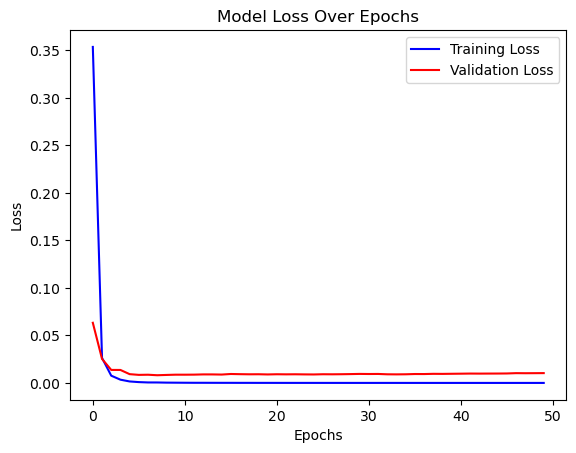

In [200]:
# Plotting the training and validation loss over epochs

plt.plot(history.history["loss"], color="b", label="Training Loss")
plt.plot(history.history["val_loss"], color="r", label="Validation Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.title("Model Loss Over Epochs")
plt.legend()
plt.show()

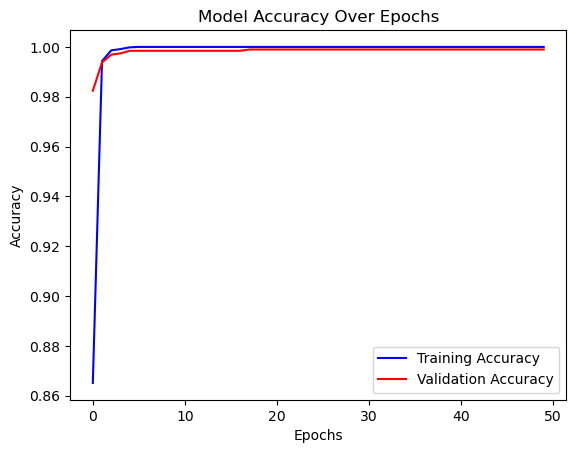

In [201]:
# Visualize accuracy over epochs

plt.plot(history.history["accuracy"], color="b", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], color="r", label="Validation Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epochs")
plt.title("Model Accuracy Over Epochs")
plt.legend()
plt.show()

In [202]:
# Define a function to display the confusion matrix and key performance metrics

def display_matrix_and_scores(y_true, y_pred):
    
    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred):.4f}")
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
    plt.title("Confusion Matrix")
    plt.show()
    


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy  : 0.9979
Precision : 0.9980
Recall    : 0.9980


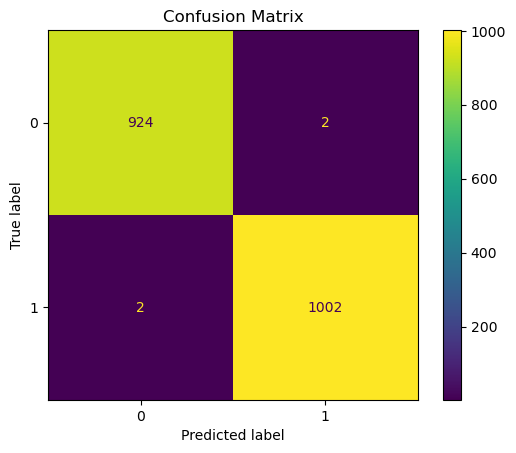

In [203]:
# Apply the function on test dataset

# Load the best saved model based on validation performance
best_model = load_model("model_1.h5")

# Make predictions on the test set (threshold of 0.5 for binary classification)
y_pred = (best_model.predict(X_test) > 0.5).astype("int32")

# Evaluate and display metrics
display_matrix_and_scores(y_test, y_pred)

The model achieves excellent performance, with an accuracy of 99.8%, a precision of 99.8%, and a recall of 99.8%. The confusion matrix shows only 2 false positives and 2 false negative, confirming the robustness of the current approach. However, we will explore more advanced methods to see if further improvements are possible.

## 3️⃣ Embedding Layer + Neural Network


In [221]:
# Count words before tokenizing

# Concatenate all cleaned messages into a single text string
all_text = " ".join(data_oversampled['message_clean'])

# Split the text into individual words and count their occurrences
word_counts = Counter(all_text.split())

# Count the total number of unique words
total_unique_words = len(word_counts)
print(f"Total number of unique words: {total_unique_words}")


Total number of unique words: 8172


In [222]:
# Tokenization

# Instantiate a tokenizer that will convert words to integer sequences
# We keep all unique words (8,172 total), since the vocabulary is relatively small
# The 'oov_token' handles words not seen during training
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=total_unique_words, oov_token="out_of_vocab")

# Fit the tokenizer on the cleaned SMS messages
tokenizer.fit_on_texts(data_oversampled['message_clean'])

# Convert the text messages to sequences of integers
data_oversampled["message_encoded"] = tokenizer.texts_to_sequences(data_oversampled['message_clean'])

In [223]:
# Pad the sequences to ensure all have the same length

# 'post' padding adds 0s at the end of sequences
message_pad = tf.keras.preprocessing.sequence.pad_sequences(data_oversampled['message_encoded'], padding="post")

# Replace the column with the padded version
data_oversampled['message_encoded'] = list(message_pad)

In [224]:
# Padding and encoding verification

data_oversampled.head()

,label,message,message_length,message_clean,message_encoded
0,1,Adult 18 Content Your video will be with you s...,52,adult 18 content video shortly,"[655, 43, 200, 70, 1136, 0, 0, 0, 0, 0, 0, 0, ..."
1,0,Then we wait 4 u lor... No need 2 feel bad lar...,49,wait 4 u lor need 2 feel bad lar,"[75, 8, 2, 107, 55, 4, 154, 427, 519, 0, 0, 0,..."
2,0,1's finish meeting call me.,27,1 finish meeting,"[44, 308, 897, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0..."
3,0,Wot is u up 2 then bitch?,25,wot u 2 bitch,"[698, 2, 4, 1297, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0..."
4,1,U have a Secret Admirer who is looking 2 make ...,158,u secret admirer look 2 contact ufind rreveal ...,"[2, 285, 313, 132, 4, 23, 360, 361, 47, 5, 362..."


In [225]:
# Definition of X and y

# Convert the padded sequences column to a NumPy array for model input
X = np.array(data_oversampled['message_encoded'].tolist())

# Define the target variable y
y = np.array(data_oversampled['label'])



In [226]:
# Perform train-test-val split - 60% train, 20% val, 20% test

# Step 1: Train + Temp (val + test)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Train + Val
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

In [227]:
# Definition of batch_length

batch_length=64

In [228]:
# Create TensorFlow datasets, shuffle and batch the datasets.

# Shuffling improves generalization by randomizing the order of samples
# Batching allows processing multiple samples in parallel

train = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(len(X_train)).batch(batch_length)
val = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_length)
test = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_length)

In [229]:
# Model definition

# Define model hyperparameters
vocab_size = total_unique_words     # Number of unique tokens in the dataset
embedding_dim = 64                  # Size of the dense embedding vectors

# Determine the maximum sequence length in the padded sequences
max_length = max(len(x) for x in dataset_2['message_encoded'])

# Define a Sequential model with an Embedding layer followed by a simple architecture
second_model = keras.Sequential([
    keras.layers.Input(shape=(max_length,)),  # Proper input definition to avoid warnings
    keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim),  # Word embedding layer
    keras.layers.GlobalAveragePooling1D(),    # Reduces the sequence dimension by averaging across time steps
    keras.layers.Dense(64, activation='relu'),# Fully connected layer with ReLU activation
    keras.layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])



In [230]:
# Compile the model: use Adam optimizer and binary cross-entropy loss

second_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(),  # Binary classification loss
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [231]:
# Define a callback to save the model with the highest validation precision

checkpoint = ModelCheckpoint(
    "model_2.h5",                 # Filepath to save the model
    monitor="val_loss",           # Metric to monitor
    save_best_only=True,          # Only save model if it improves
    mode="min",                   # Because higher precision is better
    verbose=1                     # Show a message when model is saved
)

In [232]:
# Number of epochs

epochs_number = 100

In [233]:
# Train the model using the training set and validate on the validation set

history = second_model.fit(
    train,                     # Training dataset (batched and shuffled)
    validation_data=val,       # Validation dataset to monitor model performance during training
    epochs=epochs_number,      # Number of training epochs (set by the user)
    callbacks=[checkpoint],    # Callback to save the best model (based on val_loss)
    verbose=1                  # Verbose mode: 1 = progress bar for each epoch
)


Epoch 1/100
76/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5221 - loss: 0.6848 - precision: 0.6201 - recall: 0.1082 
Epoch 1: val_loss improved from inf to 0.58426, saving model to model_2.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5354 - loss: 0.6819 - precision: 0.6597 - recall: 0.1301 - val_accuracy: 0.9145 - val_loss: 0.5843 - val_precision: 0.9844 - val_recall: 0.8433
Epoch 2/100
72/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8619 - loss: 0.5164 - precision: 0.9493 - recall: 0.7660
Epoch 2: val_loss improved from 0.58426 to 0.21421, saving model to model_2.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8672 - loss: 0.4945 - precision: 0.9522 - recall: 0.7742 - val_accuracy: 0.9451 - val_loss: 0.2142 - val_precision: 0.9843 - val_recall: 0.9052
Epoch 3/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9496 - loss: 0.1762 - precision: 0.9927 - recall: 0.9055
Epoch 3: val_loss improved from 0.21421 to 0.11098, saving model to model_2.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9496 - loss: 0.1760 - precision: 0.9927 - recall: 0.9056 - val_accuracy: 0.9549 - val_loss: 0.1110 - val_precision: 0.9911 - val_recall: 0.9186
Epoch 4/100
84/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9654 - loss: 0.1063 - precision: 0.9907 - recall: 0.9423
Epoch 4: val_loss improved from 0.11098 to 0.07926, saving model to model_2.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9657 - loss: 0.1054 - precision: 0.9907 - recall: 0.9426 - val_accuracy: 0.9705 - val_loss: 0.0793 - val_precision: 0.9924 - val_recall: 0.9485
Epoch 5/100
79/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9784 - loss: 0.0699 - precision: 0.9965 - recall: 0.9595
Epoch 5: val_loss improved from 0.07926 to 0.07559, saving model to model_2.h5


...

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9998 - loss: 0.0022 - precision: 1.0000 - recall: 0.9996 - val_accuracy: 0.9979 - val_loss: 0.0100 - val_precision: 0.9990 - val_recall: 0.9969
Epoch 48/100
85/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9993 - loss: 0.0019 - precision: 1.0000 - recall: 0.9986
Epoch 48: val_loss improved from 0.00996 to 0.00979, saving model to model_2.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9993 - loss: 0.0019 - precision: 1.0000 - recall: 0.9986 - val_accuracy: 0.9979 - val_loss: 0.0098 - val_precision: 0.9990 - val_recall: 0.9969
Epoch 49/100
81/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9998 - loss: 9.1387e-04 - precision: 1.0000 - recall: 0.9996
Epoch 49: val_loss improved from 0.00979 to 0.00951, saving model to model_2.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9998 - loss: 9.5867e-04 - precision: 1.0000 - recall: 0.9996 - val_accuracy: 0.9979 - val_loss: 0.0095 - val_precision: 0.9990 - val_recall: 0.9969
Epoch 50/100
89/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9997 - loss: 0.0016 - precision: 0.9993 - recall: 1.0000 
Epoch 50: val_loss did not improve from 0.00951
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9997 - loss: 0.0016 - precision: 0.9993 - recall: 1.0000 - val_accuracy: 0.9969 - val_loss: 0.0109 - val_precision: 0.9959 - val_recall: 0.9979
Epoch 51/100
82/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9999 - loss: 0.0013 - precision: 0.9998 - recall: 1.0000  
Epoch 51: val_loss did not improve from 0.00951
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9999 - loss: 0.0013 - precision: 0.9998 - recall: 1.0000 - val_accuracy: 0.9959 - val_loss: 0.0126 - val_precision: 0.9938 - val_recall: 0.9979
Epoch 52/100
75/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accura

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9996 - loss: 0.0019 - precision: 1.0000 - recall: 0.9991 - val_accuracy: 0.9984 - val_loss: 0.0094 - val_precision: 0.9990 - val_recall: 0.9979
Epoch 54/100
84/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9997 - loss: 0.0015 - precision: 1.0000 - recall: 0.9994
Epoch 54: val_loss did not improve from 0.00940
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9997 - loss: 0.0014 - precision: 1.0000 - recall: 0.9994 - val_accuracy: 0.9974 - val_loss: 0.0095 - val_precision: 0.9969 - val_recall: 0.9979
Epoch 55/100
83/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9999 - loss: 9.9579e-04 - precision: 1.0000 - recall: 0.9997
Epoch 55: val_loss did not improve from 0.00940
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9999 - loss: 9.9597e-04 - precision: 1.0000 - recall: 0.9997 - val_accuracy: 0.9964 - val_loss: 0.0115 - val_precision: 0.9949 - val_recall: 0.9979
Epoch 56/100
76/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accur

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9990 - loss: 0.0016 - precision: 0.9992 - recall: 0.9989 - val_accuracy: 0.9984 - val_loss: 0.0094 - val_precision: 0.9990 - val_recall: 0.9979
Epoch 62/100
88/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9990 - loss: 0.0019 - precision: 0.9994 - recall: 0.9987
Epoch 62: val_loss did not improve from 0.00935
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9991 - loss: 0.0019 - precision: 0.9994 - recall: 0.9987 - val_accuracy: 0.9979 - val_loss: 0.0095 - val_precision: 0.9979 - val_recall: 0.9979
Epoch 63/100
81/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 2.8980e-04 - precision: 1.0000 - recall: 1.0000
Epoch 63: val_loss did not improve from 0.00935
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 3.2701e-04 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9943 - val_loss: 0.0198 - val_precision: 0.9908 - val_recall: 0.9979
Epoch 64/100
83/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accur

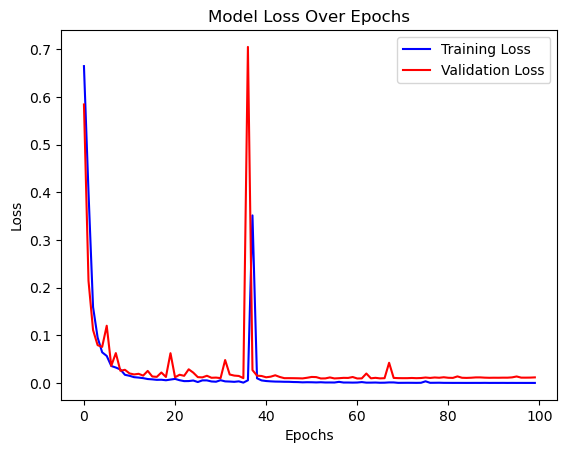

In [234]:
# Plotting the training and validation loss over epochs
plt.plot(history.history["loss"], color="b", label="Training Loss")
plt.plot(history.history["val_loss"], color="r", label="Validation Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.title("Model Loss Over Epochs")
plt.legend()
plt.show()

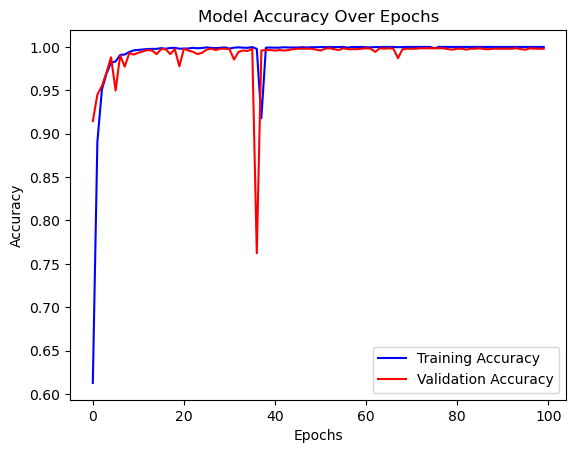

In [235]:
# Visualize accuracy over epochs

plt.plot(history.history["accuracy"], color="b", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], color="r", label="Validation Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epochs")
plt.title("Model Accuracy Over Epochs")
plt.legend()
plt.show()

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy  : 0.9969
Precision : 0.9959
Recall    : 0.9979


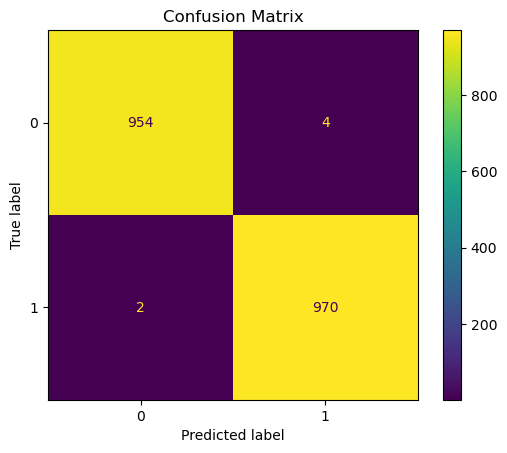

In [236]:
# Apply the function on test dataset

# Load the best saved model based on validation performance
best_model_2 = load_model("model_2.h5")

# Make predictions on the test set (threshold of 0.5 for binary classification)
y_pred = (best_model_2.predict(X_test) > 0.5).astype("int32")

# Evaluate and display metrics
display_matrix_and_scores(y_test, y_pred)

Performance remains comparable with this model, although precision is slightly lower due to more false positives. This can be particularly undesirable in the context of a spam detector, where it's generally better to allow a few spam messages through than to mistakenly classify a legitimate email as spam.

## 4️⃣ Transfer Learning with BERT (DistilBERT)


In [237]:
# import Bert Tokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

In [238]:
# Tokenizing the dataset

tokens = tokenizer(
    list(data_oversampled['message']),    # Text list
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors='pt'              # Pour PyTorch (ou 'tf' pour TensorFlow)
)


In [239]:
# Target definition

y = torch.tensor(data_over_3["label"].values)


In [ ]:
# Train test  test split and make it ready to Pytorch

labels = y  # y is an array de 0/1 (spam/ham)

dataset_model3 = TensorDataset(
    tokens['input_ids'],
    tokens['attention_mask'],
    labels
)

train_size = int(0.6 * len(dataset_model3))
val_size = int(0.2 * len(dataset_model3))
test_size = len(dataset_model3) - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    dataset_model3, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

In [241]:
# Model definition

model_3 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", 
    num_labels=2  # Spam / Ham = 2 classes
)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [246]:
# Optimizer definition

optimizer = AdamW(model_3.parameters(), lr=2e-5)


In [243]:
# model visualization

print(model_3)


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [247]:
# Equipment evaluation

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_3.to(device)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [248]:
# Epochs definition

num_epochs = 5

In [ ]:
# Model training

# Scheduler

num_training_steps = num_epochs * len(train_loader)
lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

# Tracking
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
best_val_loss = float('inf')

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    # Training
    model_3.train()
    train_loss, correct, total = 0, 0, 0
    loop = tqdm(train_loader, desc="Training", leave=False)
    for batch in loop:
        input_ids, attn_mask, labels = [b.to(device) for b in batch]

        outputs = model_3(input_ids, attention_mask=attn_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        train_loss += loss.item()
        preds = torch.argmax(logits, axis=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item())

    train_losses.append(train_loss / len(train_loader))
    train_accuracies.append(correct / total)

    # Validation
    model_3.eval()
    val_loss, correct, total = 0, 0, 0
    val_loop = tqdm(val_loader, desc="Validation", leave=False)
    with torch.no_grad():
        for batch in val_loop:
            input_ids, attn_mask, labels = [b.to(device) for b in batch]

            outputs = model_3(input_ids, attention_mask=attn_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            val_loss += loss.item()
            preds = torch.argmax(logits, axis=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            val_loop.set_postfix(loss=loss.item())

    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(correct / total)

    print(f"Train Loss: {train_losses[-1]:.4f}, Acc: {train_accuracies[-1]:.4f}")
    print(f"Val   Loss: {val_losses[-1]:.4f}, Acc: {val_accuracies[-1]:.4f}")

    # Save best model
    if val_losses[-1] < best_val_loss:
        torch.save(model_3.state_dict(), "model_3.h5")
        best_val_loss = val_losses[-1]



Epoch 1/5


Training:   0%|          | 0/121 [00:00<?, ?it/s]

Validation:   0%|          | 0/31 [00:00<?, ?it/s]

Train Loss: 0.1166, Acc: 0.9671
Val   Loss: 0.0227, Acc: 0.9922

Epoch 2/5


Training:   0%|          | 0/121 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/31 [00:00<?, ?it/s]

Train Loss: 0.0015, Acc: 1.0000
Val   Loss: 0.0119, Acc: 0.9969

Epoch 5/5


Training:   0%|          | 0/121 [00:00<?, ?it/s]

Validation:   0%|          | 0/31 [00:00<?, ?it/s]

Train Loss: 0.0012, Acc: 0.9999
Val   Loss: 0.0110, Acc: 0.9979


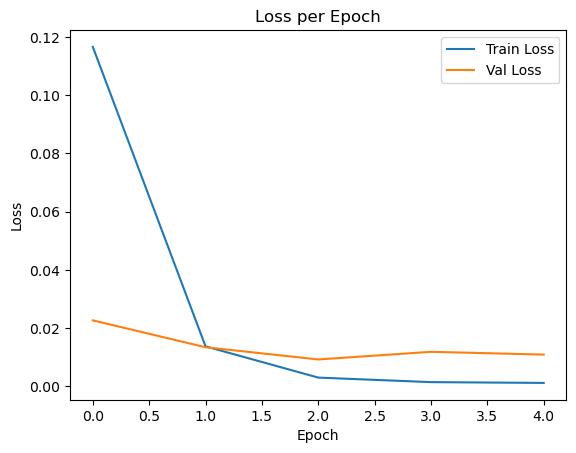

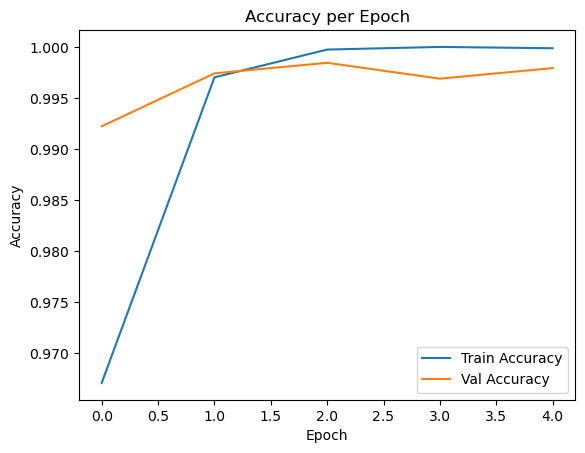

In [ ]:
# losses and accuracy plots

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss per Epoch")
plt.legend()
plt.show()

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy per Epoch")
plt.legend()
plt.show()


✅ Nombre de prédictions : 1930
✅ Nombre de vraies étiquettes : 1930


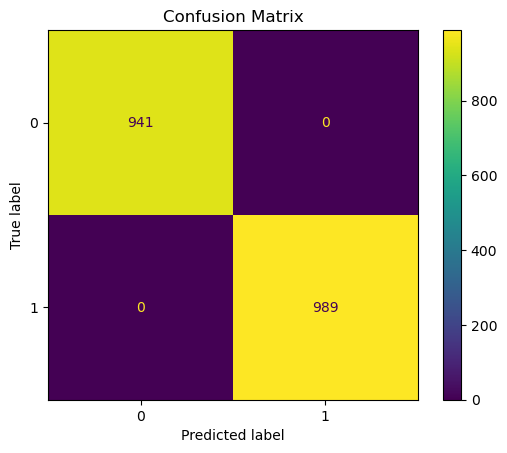

Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000


In [ ]:
# Confusion matrix and scoring display


# best model loading

model_3.load_state_dict(torch.load("model_3.h5"))
model_3.eval().to(device)

# Evaluation
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader: 
        input_ids, attention_mask, labels = batch
        outputs = model_3(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, axis=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# Scores
print(f"Accuracy  : {accuracy_score(all_labels, all_preds):.4f}")
print(f"Precision : {precision_score(all_labels, all_preds):.4f}")
print(f"Recall    : {recall_score(all_labels, all_preds):.4f}")

# Print confusion matrix
ConfusionMatrixDisplay.from_predictions(all_labels, all_preds)
plt.title("Confusion Matrix")
plt.show()




This qmodel is quite heavier than previous (261Mo vs 12Mo for tf-idf simple NN and 6Mo for embedding). For example even generate the confusion matrix take a couple of mi,nutes to predicts only about 2000mail. Even if performances are slightly better, it's not interesting to stoere and deploy such an heavy file.

## 5️⃣ Conclusion